In [16]:
from pathlib import Path
import os
import pandas as pd

conn_list = pd.read_csv("/home/galkepler/Projects/neuroaging/Connetcome List.csv")


In [17]:
qnap_df = pd.read_pickle("/home/galkepler/Projects/qnap_mapping/mapped_qnap.pkl")

In [23]:
qnap_by_id = qnap_df[qnap_df["id"].astype(str).str.zfill(9).isin(conn_list["ID "].astype(str).str.zfill(9))].drop_duplicates(subset=["id"])
dobs_by_id = (
    qnap_by_id.set_index(qnap_by_id["id"].astype(str).str.zfill(9))["dob"]
    .apply(lambda x: pd.to_datetime(x, format="%d/%m/%Y"))
    .to_dict()
)
sex_by_id = qnap_by_id.set_index(qnap_by_id["id"].astype(str).str.zfill(9))["sex"].to_dict()

conn_list["dob"] = conn_list["ID "].astype(str).str.zfill(9).map(dobs_by_id)
conn_list["sex"] = conn_list["ID "].astype(str).str.zfill(9).map(sex_by_id).map({"Male":"M", "Female":"F"})
conn_list["session_id"] = conn_list["ScanID"].astype(str).str.replace("_","")
conn_list["session_timestamp"] = pd.to_datetime(
    conn_list["session_id"], format="%Y%m%d%H%M"
)
conn_list["age_at_scan"] = (conn_list["session_timestamp"] - conn_list["dob"]).dt.days / 365.25

In [25]:
conn_list.to_csv(
    "/home/galkepler/Projects/learning_for_luna/src/learning_for_luna/chapters/chapter_1/yaniv_vip_legacy_mprage.csv"
)

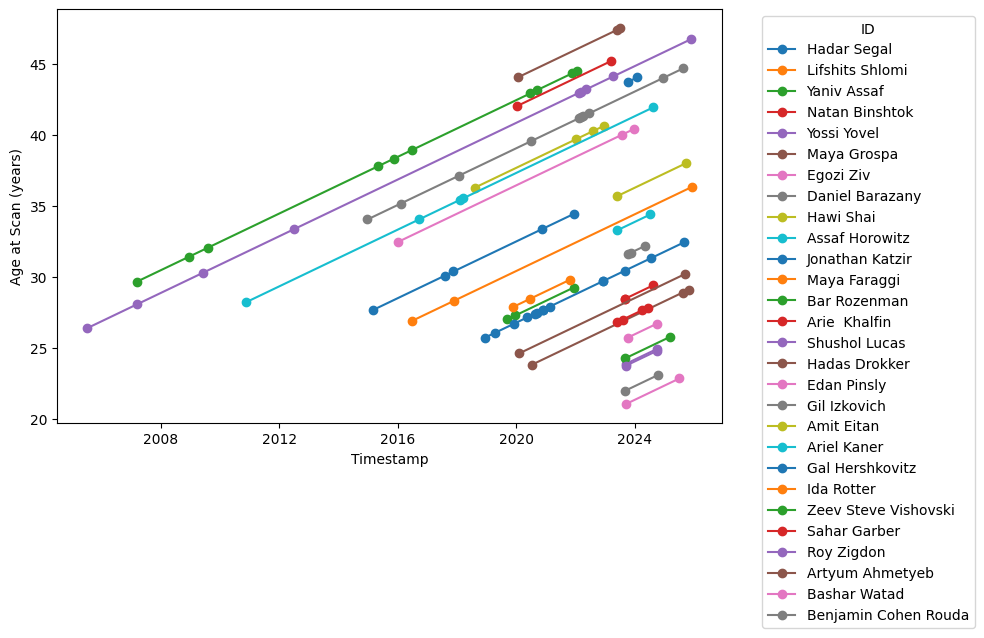

In [4]:
# plot age_at_scan by session_id for each ID
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
for id_, group in conn_list.groupby("ID "):
    name = group["Name"].iloc[0]
    ax.plot(group["session_timestamp"], group["age_at_scan"], marker="o", label=name)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Age at Scan (years)")
ax.legend(title="ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [5]:
conn_list = conn_list[conn_list["visual_BAG"].isna()]


In [26]:
source_data_path = Path("/mnt/gal_legacy/4Gal2/4Gal/")
bids_destination = Path("/media/storage/yalab-dev/anonym_bids/")
t1w_files = []
for idx, row in conn_list.iterrows():
    subject_code = str(row["ID "]).zfill(9)
    scan_id = row["ScanID"]
    session_id = str(scan_id).replace("_","")
    session_source_path = source_data_path / scan_id
    dest = bids_destination / f"sub-{subject_code}" / f"ses-{session_id}" / "anat"
    # dest.mkdir(parents=True, exist_ok=True)
    # if not session_source_path.exists():
    #     print(f"Source path does not exist: {session_source_path}")
    #     continue
    # if session_id.startswith("2025"):
    #     print(f"Skipping future session: {session_id}")
    #     continue
    flag = dest / f"sub-{subject_code}_ses-{session_id}_ce-corrected_T1w.nii"
    if flag.exists():
        t1w_files.append(flag)
        # print(f"Already converted: {flag}, unzipping if necessary.")
        # os.system(f"gunzip {flag}")

        continue
    # convert dicom to BIDS using dcm2niix
    # os.system(f"dcm2niix -z y -f sub-{subject_code}_ses-{session_id}_ce-corrected_T1w -o {dest} {session_source_path}")
    
    

In [29]:
# t1w_files = [str(f) for f in t1w_files]
conn_list.loc[conn_list["ID "] == 37564101]

,ScanID,ID,Name,visual_BAG,somatomotor_BAG,dorsal attention_BAG,salience / ventral attention_BAG,limbic_BAG,control_BAG,default_BAG,subcortex_BAG,dob,session_id,session_timestamp,age_at_scan,sex
25,20200116_1244,37564101,Maya Grospa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1975-12-22,202001161244,2020-01-16 12:44:00,44.068446,M
26,20230529_1155,37564101,Maya Grospa,-0.96341,-2.98335,-2.03569,1.870955,-1.88981,3.175123,3.067117,-6.06897,1975-12-22,202305291155,2023-05-29 11:55:00,47.433265,M
27,20230705_1606,37564101,Maya Grospa,-0.70264,-2.54314,-1.83027,1.524422,-2.07497,2.625953,2.891638,-7.35689,1975-12-22,202307051606,2023-07-05 16:06:00,47.534565,M


In [15]:
printed = []
for f in t1w_files:
    if f is None:
        continue
    subject = f.name.split("_")[0].replace("sub-", "")
    # if "legacy" in subject:
    #     print(f"'{f},1'")
    # if subject in BAD_SUBJECTS:
    #     continue
    if f not in printed and ("legacy" not in subject):
        print(f"'{f},1'")

        printed.append(f)
# t1w_files


'/media/storage/yalab-dev/anonym_bids/sub-029493145/ses-202006181633/anat/sub-029493145_ses-202006181633_ce-corrected_T1w.nii,1'
'/media/storage/yalab-dev/anonym_bids/sub-029493145/ses-202009071524/anat/sub-029493145_ses-202009071524_ce-corrected_T1w.nii,1'
'/media/storage/yalab-dev/anonym_bids/sub-029493145/ses-202111171016/anat/sub-029493145_ses-202111171016_ce-corrected_T1w.nii,1'
'/media/storage/yalab-dev/anonym_bids/sub-029493145/ses-202201201355/anat/sub-029493145_ses-202201201355_ce-corrected_T1w.nii,1'
'/media/storage/yalab-dev/anonym_bids/sub-031440266/ses-202001121817/anat/sub-031440266_ses-202001121817_ce-corrected_T1w.nii,1'
'/media/storage/yalab-dev/anonym_bids/sub-031440266/ses-202303081309/anat/sub-031440266_ses-202303081309_ce-corrected_T1w.nii,1'
'/media/storage/yalab-dev/anonym_bids/sub-036385151/ses-202304111049/anat/sub-036385151_ses-202304111049_ce-corrected_T1w.nii,1'
'/media/storage/yalab-dev/anonym_bids/sub-036385151/ses-202511171318/anat/sub-036385151_ses-20251